<a href="https://www.kaggle.com/code/shravankumarpandey/sentiment-analysis-using-langgraph?scriptVersionId=335639052" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GROQ_API_KEY")

In [2]:
pip install langchain-google-genai

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install langchain-groq

Note: you may need to restart the kernel to use updated packages.


# 1.Importing the Libraries

In [4]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
from langchain_groq import ChatGroq

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


# 2.Defining LLM

In [5]:
llm=llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=secret_value_0
)

# 3.Defining Sentiment Schema

In [6]:
class SentimentSchema(BaseModel):
    sentiment:Literal["positive","negative"]=Field(description="Sentiment of the review")

# Diagnosis Schema

In [7]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

## 3.1 Structured Output

In [8]:
model=llm.with_structured_output(SentimentSchema)
model1=llm.with_structured_output(DiagnosisSchema)

## 3.2 Defining Sentiment State

In [9]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal["positive","negative"]
    diagnosis:dict
    response:str

# 4.Defining Node

## 4.1 Sentiment Node

In [10]:
def Sentiment_Node(state:ReviewState)->ReviewState:
    prompt=f"for the following review fiind out the sentiment:\n {state['review']}"
    sentiment= model.invoke(prompt).sentiment
    return {"sentiment":sentiment}

## 4.2 Function for checking the condition

In [11]:
def check_sentiment(state:ReviewState)->Literal["positive_response","run_diagnosis"]:
    sentiment=state["sentiment"]
    if sentiment=="positive":
        return "positive_response"
    else:
        return "run_diagnosis"
    

## 4.3 Definition of Postive Response Node

In [12]:
def positive_response(state:ReviewState)->ReviewState:
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website."""
    response = model.invoke(prompt).content
    return {"response":response}

## 4.4 Definition of Diagnosis Node

In [13]:
def run_diagnosis(state:ReviewState)->ReviewState:
    prompt=f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency."""
    
    response=model1.invoke(prompt)
    
    return {"diagnosis":response.model_dump()}

## 4.5 Definition of Negative response Node

In [14]:
def negative_response(state:ReviewState)->ReviewState:
    diagnosis=state["diagnosis"]
    prompt=f"""You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
    """
    response = llm.invoke(prompt).content
    
    return {"response":response}
    

# 5.Adding Node

In [15]:
graph=StateGraph(ReviewState)
graph.add_node("Sentiment_Node",Sentiment_Node)
graph.add_node("positive_response",positive_response)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("negative_response",negative_response)

# 6.Adding Edges

In [16]:
graph.add_edge(START,"Sentiment_Node")
graph.add_conditional_edges("Sentiment_Node",check_sentiment)
graph.add_edge("positive_response",END)
graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("negative_response",END)

# 7.Workflow or Compilation

In [17]:
workflow=graph.compile()

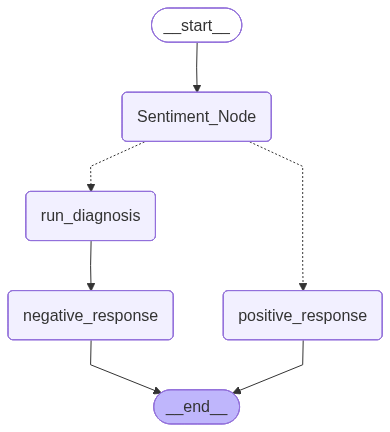

In [18]:
workflow

# 8.Initial State

In [19]:
initial_state={
    "review":"I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

# 9.Final Result

In [20]:
result=workflow.invoke(initial_state)

In [21]:
print(result)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.', 'sentiment': 'negative', 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'}, 'response': "I'm so sorry to hear that you're experiencing a bug issue and that it's causing you frustration. I can imagine how annoying it must be to deal with, and I'm here to help resolve it as quickly as possible.\n\nI've reviewed your report and I'm treating this with the highest urgency. I want to assure you that I'm committed to finding a solution and getting things back to normal for you.\n\nTo better understand the issue, could you please provide me with more details about the bug you're experiencing? This will help me to investigate and identify the root cause more efficiently. Additionally, I may need to ask you a few questions or request 

In [22]:
print(result["sentiment"])

negative


In [23]:
print(result["diagnosis"])

{'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'}


In [24]:
print(result["response"])

I'm so sorry to hear that you're experiencing a bug issue and that it's causing you frustration. I can imagine how annoying it must be to deal with, and I'm here to help resolve it as quickly as possible.

I've reviewed your report and I'm treating this with the highest urgency. I want to assure you that I'm committed to finding a solution and getting things back to normal for you.

To better understand the issue, could you please provide me with more details about the bug you're experiencing? This will help me to investigate and identify the root cause more efficiently. Additionally, I may need to ask you a few questions or request some troubleshooting steps to be taken.

Please know that I'm here to listen and help. I appreciate your patience and cooperation, and I'll do my best to provide a prompt and effective resolution. Your satisfaction is my top priority, and I'll work tirelessly to ensure that the issue is resolved to your satisfaction.

If there's anything I can do in the mea